# Model Extension Workflow

Gendantic provides two functions to incrementally enhance your models:

1. **`extend_model_with_distributions()`**: Add statistical distributions to a basic model
2. **`extend_model_with_correlations()`**: Add correlations to a model with distributions

This allows you to:
- Start with a simple Pydantic model
- Let the LLM suggest appropriate distributions
- Let the LLM suggest realistic correlations

In [1]:
from typing import Annotated

import numpy as np
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field

from gendantic import (
    generate_synthetic_data,
    extend_model_with_distributions,
    extend_model_with_correlations,
    Normal,
    Uniform,
)

plt.style.use('seaborn-v0_8-whitegrid')

## Step 1: Start with a Basic Model

Define a simple Pydantic model without any distributions:

In [2]:
class Employee(BaseModel):
    """Employee record for HR analytics."""
    name: str
    email: str
    age: int
    years_experience: int
    salary: float
    department: str
    performance_score: float = Field(ge=0, le=1)

print("Basic model fields:")
for name, field in Employee.model_fields.items():
    print(f"  {name}: {field.annotation}")

Basic model fields:
  name: <class 'str'>
  email: <class 'str'>
  age: <class 'int'>
  years_experience: <class 'int'>
  salary: <class 'float'>
  department: <class 'str'>
  performance_score: <class 'float'>


## Step 2: Add Distributions

Let the LLM suggest appropriate distributions based on field semantics:

In [3]:
DistributedEmployee, dist_code = await extend_model_with_distributions(Employee)

print("Model with distributions:")
print("-" * 50)
print(dist_code)
print("-" * 50)

Model with distributions:
--------------------------------------------------
class Employee(BaseModel):
    """Employee record for HR analytics."""
    name: str
    email: str
    age: Annotated[int, Uniform(min=22, max=65)]
    years_experience: Annotated[int, Uniform(min=0, max=40)]
    salary: Annotated[float, LogNormal(mean=75000, sigma=0.5)]
    department: Annotated[str, Categorical(weights={"Engineering": 0.4, "Sales": 0.3, "HR": 0.2, "Marketing": 0.1})]
    performance_score: Annotated[float, Beta(alpha=2, beta=5)]

--------------------------------------------------


In [4]:
# Generate data with the distributed model
employees = await generate_synthetic_data(DistributedEmployee, count=5, seed=42)

print("\nGenerated employees:")
for emp in employees:
    print(f"\n{emp.name} ({emp.email})")
    print(f"  Age: {emp.age} | Experience: {emp.years_experience} yrs")
    print(f"  Salary: £{emp.salary:,.0f} | Dept: {emp.department}")
    print(f"  Performance: {emp.performance_score:.2f}")


Generated employees:

John Doe (john.doe@engineering.com)
  Age: 55 | Experience: 39 yrs
  Salary: £inf | Dept: Engineering
  Performance: 0.16

Susan Smith (susan.smith@sales.com)
  Age: 41 | Experience: 30 yrs
  Salary: £inf | Dept: Sales
  Performance: 0.17

Mark Johnson (mark.johnson@engineering.com)
  Age: 59 | Experience: 31 yrs
  Salary: £inf | Dept: Engineering
  Performance: 0.38

Anna White (anna.white@hr.com)
  Age: 52 | Experience: 5 yrs
  Salary: £inf | Dept: HR
  Performance: 0.37

Chris Jones (chris.jones@sales.com)
  Age: 26 | Experience: 18 yrs
  Salary: £inf | Dept: Sales
  Performance: 0.11


## Step 3: Add Correlations

Now let the LLM suggest realistic correlations between the distribution fields:

In [5]:
CorrelatedEmployee, corr_code = await extend_model_with_correlations(DistributedEmployee)

print("Model with correlations:")
print("-" * 50)
print(corr_code)
print("-" * 50)

Model with correlations:
--------------------------------------------------
class Employee(BaseModel):
    """Employee record for HR analytics."""
    name: str
    email: str
    age: Annotated[int, Uniform(min=22, max=65)]
    years_experience: Annotated[int, Uniform(min=0, max=40)]
    salary: Annotated[float, LogNormal(mean=75000, sigma=0.5)]
    department: Annotated[str, Categorical(weights={'Engineering': 0.4, 'Sales': 0.3, 'HR': 0.2, 'Marketing': 0.1})]
    performance_score: Annotated[float, Beta(alpha=2, beta=5)]

    __correlations__ = Correlations(
        ("age", "years_experience", 0.75),
        ("years_experience", "salary", 0.6),
        ("age", "salary", 0.5),
        ("performance_score", "salary", 0.65, "gumbel"),
        ("performance_score", "years_experience", 0.55),
    )
--------------------------------------------------


/Users/ben.rowell/Development/gendantic/src/gendantic/distributions.py:209: RuntimeWarning: overflow encountered in exp
  return stats.lognorm.ppf(u, s=self.sigma, scale=np.exp(self.mean))
/Users/ben.rowell/Development/gendantic/.venv/lib/python3.12/site-packages/scipy/stats/_distn_infrastructure.py:2323: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc


Correlation matrix:
  Age-Experience: 0.69
  Experience-Salary: nan
  Performance-Salary: nan


/Users/ben.rowell/Development/gendantic/.venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:2908: RuntimeWarning: invalid value encountered in subtract
  X -= avg[:, None]


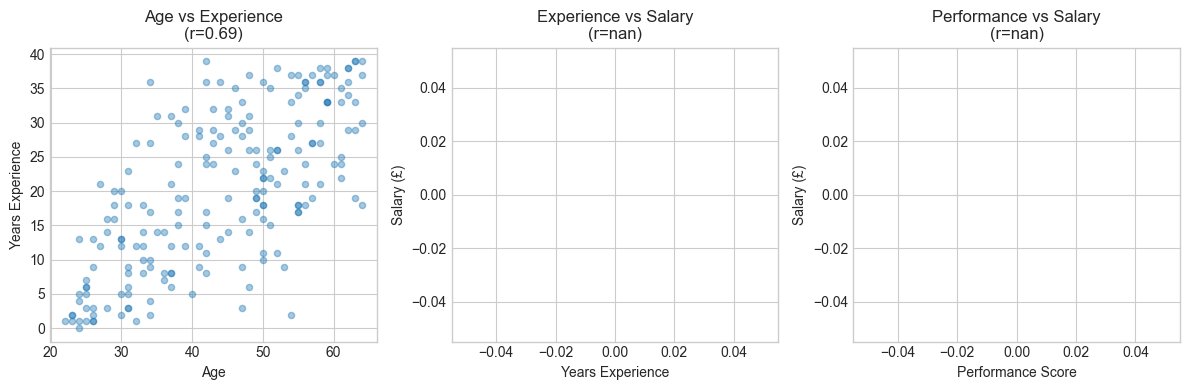

In [6]:
# Generate data with correlations
correlated_employees = await generate_synthetic_data(CorrelatedEmployee, count=200, seed=42)

# Verify correlations
ages = [e.age for e in correlated_employees]
exp = [e.years_experience for e in correlated_employees]
sal = [e.salary for e in correlated_employees]
perf = [e.performance_score for e in correlated_employees]

print("Correlation matrix:")
print(f"  Age-Experience: {np.corrcoef(ages, exp)[0,1]:.2f}")
print(f"  Experience-Salary: {np.corrcoef(exp, sal)[0,1]:.2f}")
print(f"  Performance-Salary: {np.corrcoef(perf, sal)[0,1]:.2f}")

# Visualize the correlations
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].scatter(ages, exp, alpha=0.4, s=20)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Years Experience')
axes[0].set_title(f'Age vs Experience\n(r={np.corrcoef(ages, exp)[0,1]:.2f})')

axes[1].scatter(exp, sal, alpha=0.4, s=20, color='green')
axes[1].set_xlabel('Years Experience')
axes[1].set_ylabel('Salary (£)')
axes[1].set_title(f'Experience vs Salary\n(r={np.corrcoef(exp, sal)[0,1]:.2f})')

axes[2].scatter(perf, sal, alpha=0.4, s=20, color='orange')
axes[2].set_xlabel('Performance Score')
axes[2].set_ylabel('Salary (£)')
axes[2].set_title(f'Performance vs Salary\n(r={np.corrcoef(perf, sal)[0,1]:.2f})')

plt.tight_layout()
plt.show()

In [7]:
# Notice how values make sense together
print("\nSample correlated employees:")
for emp in correlated_employees[:5]:
    print(f"  Age {emp.age}, {emp.years_experience} yrs exp, £{emp.salary:,.0f}, perf {emp.performance_score:.2f}")


Sample correlated employees:
  Age 27, 21 yrs exp, £inf, perf 0.36
  Age 58, 36 yrs exp, £inf, perf 0.40
  Age 42, 15 yrs exp, £inf, perf 0.13
  Age 56, 35 yrs exp, £inf, perf 0.35
  Age 37, 21 yrs exp, £inf, perf 0.36


## Full Workflow Example: Sales Data

In [8]:
# Step 1: Basic model
class SalesRecord(BaseModel):
    """Sales transaction record."""
    customer_name: str
    product_name: str
    deal_value: float
    units_sold: int
    discount_pct: float = Field(ge=0, le=0.5)
    days_to_close: int
    region: str

print("Step 1: Basic model defined")

Step 1: Basic model defined


In [9]:
# Step 2: Add distributions
DistributedSales, sales_dist_code = await extend_model_with_distributions(SalesRecord)

print("Step 2: Distributions added")
print(sales_dist_code)

Step 2: Distributions added
class SalesRecord(BaseModel):
    """Sales transaction record."""
    customer_name: str
    product_name: str
    deal_value: Annotated[float, LogNormal(mean=500, sigma=1)]
    units_sold: Annotated[int, Poisson(lam=10)]
    discount_pct: Annotated[float, Beta(alpha=2, beta=3)]
    days_to_close: Annotated[int, Exponential(scale=5)]
    region: Annotated[str, Categorical(weights={"North": 0.4, "South": 0.3, "East": 0.2, "West": 0.1})]


In [10]:
# Step 3: Add correlations
CorrelatedSales, sales_corr_code = await extend_model_with_correlations(DistributedSales)

print("Step 3: Correlations added")
print(sales_corr_code)

Step 3: Correlations added
class SalesRecord(BaseModel):
    """Sales transaction record."""
    customer_name: str
    product_name: str
    deal_value: Annotated[float, LogNormal(mean=500, sigma=1)]
    units_sold: Annotated[int, Poisson(lam=10)]
    discount_pct: Annotated[float, Beta(alpha=2, beta=3)]
    days_to_close: Annotated[int, Exponential(scale=5)]
    region: Annotated[str, Categorical(weights={'North': 0.4, 'South': 0.3, 'East': 0.2, 'West': 0.1})]

    __correlations__ = Correlations(
        ("deal_value", "units_sold", 0.6, "gumbel"),
        ("discount_pct", "deal_value", -0.7),
        ("days_to_close", "units_sold", 0.4),
        ("region", "deal_value", 0.5),
        ("region", "units_sold", 0.5),
    )


In [11]:
# Generate final data
sales = await generate_synthetic_data(CorrelatedSales, count=5, seed=42)

print("\nGenerated sales records:")
for s in sales:
    print(f"\n{s.customer_name} - {s.product_name}")
    print(f"  Value: £{s.deal_value:,.0f} | Units: {s.units_sold} | Discount: {s.discount_pct:.1%}")
    print(f"  Region: {s.region} | Days to close: {s.days_to_close}")


Generated sales records:

John Doe - High-Performance Laptop
  Value: £6,644,455,213,850,601,144,639,019,613,121,891,203,200,792,949,323,254,104,753,388,138,196,057,063,641,243,789,961,072,267,274,827,666,043,996,340,627,149,742,263,745,248,886,812,096,306,115,250,912,673,078,831,195,396,261,165,924,325,291,978,276,620,715,373,250,687,619,512,765,029,285,888 | Units: 12 | Discount: 66.1%
  Region: South | Days to close: 3

Jane Smith - Smart Home Device
  Value: £44,311,048,998,546,451,852,887,795,155,750,192,092,225,974,136,290,740,515,200,261,541,298,800,700,291,171,209,349,799,156,653,589,377,751,655,602,897,703,692,908,863,192,563,479,138,853,183,738,307,174,467,085,908,027,620,095,138,099,383,141,099,267,278,387,267,370,012,063,960,993,366,016 | Units: 13 | Discount: 19.1%
  Region: East | Days to close: 6

Emily Johnson - Wireless Earbuds
  Value: £9,743,189,013,240,761,575,552,771,835,654,538,352,975,142,067,222,312,085,038,495,368,773,393,720,469,225,701,093,451,356,014,327,76

## Starting from a Model with Distributions

If you already have a model with distributions, you can go directly to adding correlations:

In [12]:
class Project(BaseModel):
    """Project tracking model."""
    project_name: str
    team_size: Annotated[int, Uniform(min=2, max=20)]
    budget: Annotated[float, Normal(mean=100000, std=50000)]
    duration_weeks: Annotated[int, Uniform(min=4, max=52)]
    complexity_score: Annotated[float, Uniform(min=0, max=1)]

# Skip extend_model_with_distributions, go straight to correlations
CorrelatedProject, project_code = await extend_model_with_correlations(Project)

print("Model with correlations:")
print(project_code)

Model with correlations:
class Project(BaseModel):
    """Project tracking model."""
    project_name: str
    team_size: Annotated[int, Uniform(min=2, max=20)]
    budget: Annotated[float, Normal(mean=100000, std=50000)]
    duration_weeks: Annotated[int, Uniform(min=4, max=52)]
    complexity_score: Annotated[float, Uniform(min=0, max=1)]

    __correlations__ = Correlations(
        ("team_size", "complexity_score", -0.4),
        ("budget", "duration_weeks", 0.6, "gumbel"),
        ("complexity_score", "duration_weeks", 0.5),
    )


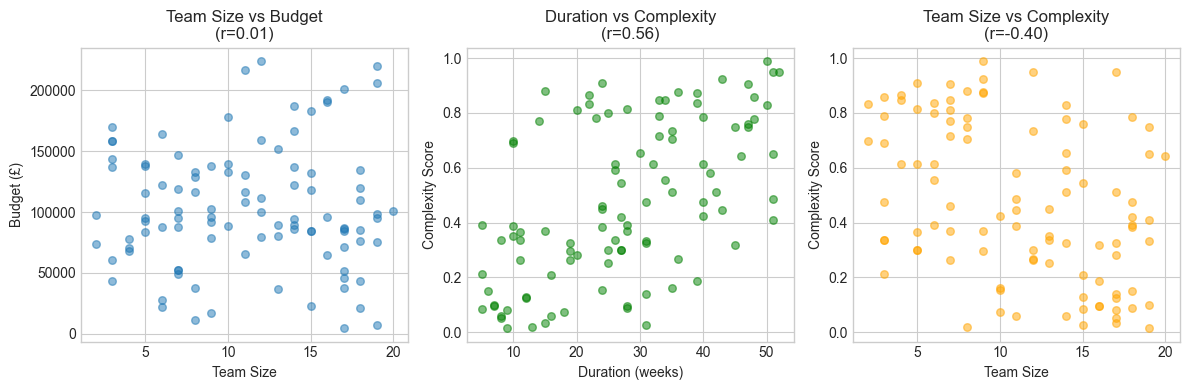


Sample projects:
  Advanced Data Analytics: Team 14, £166,378, 31wks, complexity 0.33
  Quick Dev Sprint: Team 19, £74,988, 9wks, complexity 0.01
  E-commerce Platform Revamp: Team 13, £151,659, 25wks, complexity 0.25


In [13]:
projects = await generate_synthetic_data(CorrelatedProject, count=100, seed=42)

# Extract data
team_sizes = [p.team_size for p in projects]
budgets = [p.budget for p in projects]
durations = [p.duration_weeks for p in projects]
complexity = [p.complexity_score for p in projects]

# Visualize correlations
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].scatter(team_sizes, budgets, alpha=0.5, s=30)
axes[0].set_xlabel('Team Size')
axes[0].set_ylabel('Budget (£)')
axes[0].set_title(f'Team Size vs Budget\n(r={np.corrcoef(team_sizes, budgets)[0,1]:.2f})')

axes[1].scatter(durations, complexity, alpha=0.5, s=30, color='green')
axes[1].set_xlabel('Duration (weeks)')
axes[1].set_ylabel('Complexity Score')
axes[1].set_title(f'Duration vs Complexity\n(r={np.corrcoef(durations, complexity)[0,1]:.2f})')

axes[2].scatter(team_sizes, complexity, alpha=0.5, s=30, color='orange')
axes[2].set_xlabel('Team Size')
axes[2].set_ylabel('Complexity Score')
axes[2].set_title(f'Team Size vs Complexity\n(r={np.corrcoef(team_sizes, complexity)[0,1]:.2f})')

plt.tight_layout()
plt.show()

print("\nSample projects:")
for p in projects[:3]:
    print(f"  {p.project_name}: Team {p.team_size}, £{p.budget:,.0f}, {p.duration_weeks}wks, complexity {p.complexity_score:.2f}")

## Workflow Summary

```
Basic Model
    │
    ▼  extend_model_with_distributions()
Model with Distributions
    │
    ▼  extend_model_with_correlations()
Model with Distributions + Correlations
    │
    ▼  generate_synthetic_data()
Realistic Synthetic Data
```

Benefits:
- **Incremental**: Add complexity step by step
- **Inspectable**: See what the LLM suggests at each step
- **Controllable**: Start with manual distributions, only use LLM for correlations
- **Reproducible**: Save the generated code for future use

## Saving Generated Models

The generated code can be saved and reused:

In [14]:
# Save the final model code to a file
final_code = f'''
from typing import Annotated
from pydantic import BaseModel, Field
from gendantic import Normal, Uniform, Categorical, Correlations

{sales_corr_code}
'''

print("Code ready to save to a .py file:")
print(final_code)

Code ready to save to a .py file:

from typing import Annotated
from pydantic import BaseModel, Field
from gendantic import Normal, Uniform, Categorical, Correlations

class SalesRecord(BaseModel):
    """Sales transaction record."""
    customer_name: str
    product_name: str
    deal_value: Annotated[float, LogNormal(mean=500, sigma=1)]
    units_sold: Annotated[int, Poisson(lam=10)]
    discount_pct: Annotated[float, Beta(alpha=2, beta=3)]
    days_to_close: Annotated[int, Exponential(scale=5)]
    region: Annotated[str, Categorical(weights={'North': 0.4, 'South': 0.3, 'East': 0.2, 'West': 0.1})]

    __correlations__ = Correlations(
        ("deal_value", "units_sold", 0.6, "gumbel"),
        ("discount_pct", "deal_value", -0.7),
        ("days_to_close", "units_sold", 0.4),
        ("region", "deal_value", 0.5),
        ("region", "units_sold", 0.5),
    )

